# Problem Setup

Consider a square plate with sides [−1,1]×[−1,1]
. At time t = 0 we are heating the plate up such that the temperature is 𝑢=5
 on one side and 𝑢=0
 on the other sides. The temperature evolves according to:

𝑢𝑡=Δ𝑢
.

At what time 𝑡∗
 does the plate reach 𝑢=1
 at the center of the plate?
Implement a finite difference scheme and try with explicit and implicit time-stepping.



In [2]:
# Import modules
import numpy as np
import matplotlib.pyplot as plt
import math as math

from numba import njit, prange, float64, int64
from numba import cuda

import time

## initialisations

Create plate code and index relevant boundary conditions to compute du/dt = Au for flat u and five point stencil matrix A for Euler forward method.

In [3]:
N = 21

def A_row_indices(N):
    '''
    Compute relevant row indices for dt matrix A account for boundary conditions
    '''
    assert N % 2 == 1, "N must be odd to ensure a definite centre term."
    assert N > 2, "N must be greater than 2 to define a valid grid."

    # 1. Create a 1D array of all indices: [0, 1, 2, ..., N**2 - 1]
    # 2. Reshape it into an N x N 2D grid
    # 3. Slice it to remove the first/last rows and first/last columns: [1:-1, 1:-1]
    # 4. Flatten it back to a 1D array

    return np.arange(N**2).reshape(N, N)[1:-1, 1:-1].flatten()

indices = A_row_indices(N)
print(indices.dtype)

int64


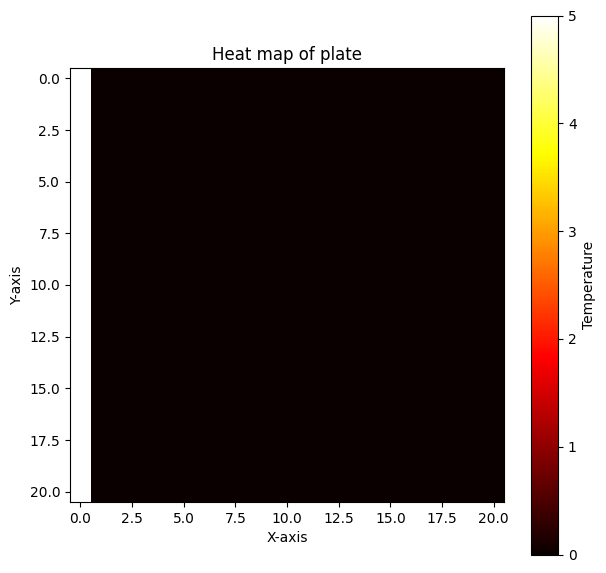

In [4]:
# Plot for intial conditions flat_plate
# Boundary conditions are properly applied

def plot_plate(matrix, N):
    """
    Plot the 2D heat map given matrix
    """
    dense_matrix = matrix.reshape(N, N)
    plt.figure(figsize=(7, 7))
    plt.imshow(dense_matrix, cmap='hot', interpolation='nearest')
    plt.colorbar(label='Temperature')
    plt.title('Heat map of plate')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

N = 21
plate = np.zeros(shape = (N,N), dtype = np.float64)
plate[:,0] = 5

plot_plate(plate.flatten(),N)


## CPU iteration

Using above initalisations leveraged Numba to create a time iteration program for plate u cutting off at u centre (index (N//2)*N + (N//2)) >=1

Note assertion on C is a result of the CFL condition and will be explained later.

In [5]:
@njit(parallel=True)
def time_step(u,v,indi,c,N):
    """
    Performs one timestep of the 5-point stencil update on the plate.
    """
    for row in prange(len(indi)):
        i = indi[row]
        v[i] = u[i] - (4*u[i] - u[i-1] - u[i+1] - u[i-N] - u[i+N]) * c
    return v

def Numba_CPU_timemachine(N, dt, u_start=None, t_start=0.0, sf = 1):
    """
    Simulates the temperature distribution on a plate until the center reaches 1.0.
    """

    # Compute parameters
    h = 2 / (N - 1)  # Spatial step size
    C = ((N - 1)**2 * dt / 4)  # dt/h^2 , h = 2/(N-1).
    assert C <= 0.25, "C must be less than or equal to 1/4 for stability."

    print("CPU_Numba")
    print(f"N: {N}")
    print(f"dt: {dt}")
    print(f"C: {C}")

    # Initialise plate
    if u_start is None:
      plate = np.zeros(shape = (N,N), dtype = np.float64)
      plate[:,0] = 5 * sf
      u = plate.flatten()
    else:
        u = u_start

    indices = A_row_indices(N)
    CI = (N // 2) * (N + 1) # Center index
    v = np.copy(u)

    # Run once to trigger JIT compilation before timing
    _ = time_step(u, v, indices, C, N)

    # Start simulation
    i = 0
    start_time = time.time()

    # Loop until the center reaches at least 1.0
    while u[CI] < 1.0 * sf:
        v = time_step(u, v, indices, C, N)
        u, v = v, u # Swap u and v for next step
        i += 1

        # Print progress every 200 iterations
        if i % 200 == 0:
            print(f"\rIteration {i}, Centre point u = {u[CI]:.12f}, t = {t_start + i*dt:.12f}",
                  end="", flush=True)

    end_time = time.time()
    runtime = end_time - start_time

    t = t_start + i*dt  # Final time

    print(f"\nFinished at iteration {i}, u_cen: {u[CI]} t: {t:.12f}")
    print(f"Runtime: {runtime:.16f} seconds")

    return {
        "final_state": u,
        "final_time": t,
        "runtime": runtime
    }

Maximum timestep dt is 2.450740123517302e-05:
CPU_Numba
N: 201
dt: 2.5e-05
C: 0.25
Iteration 16800, Centre point u = 0.995037243471, t = 0.420000000000
Finished at iteration 16960, u_cen: 1.0000176929727616 t: 0.424000000000
Runtime: 6.3504786491394043 seconds


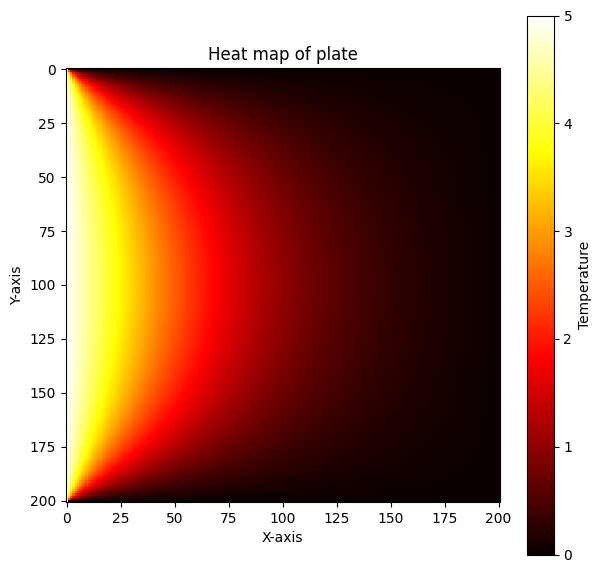

In [6]:
N = 201
dt = 1/(N-1)**2  #1/(N-1)**2 Largest possible dt while remaining stable
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res = Numba_CPU_timemachine(N, dt)

plot_plate(res['final_state'],N)

## GPU iteration
Using same principal as above implimented a GPU scheme for time evolution facilitating data collection for larger N and smaller time steps (dt).

In [7]:
# Get GPU information
cuda.detect()

Found 1 CUDA devices
id 0                Tesla T4                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-0fc535c3-de53-0acb-66df-7c783d46dfd8
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported


True

In [8]:
# Define block dimensions for 2D grid
BLOCK_DIM = 16

@cuda.jit
def cuda_timestep_shared(u, v, N, c):
    """
    Performs one timestep of the 5-point stencil update using Shared Memory.
    """
    # Allocate shared memory: 16x16 tile + 1 cell halo on all sides = 18x18
    s_u = cuda.shared.array(shape=(18, 18), dtype=float64)

    # Local thread coordinates within the block
    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    # Global grid coordinates
    row = cuda.blockIdx.y * cuda.blockDim.y + ty
    col = cuda.blockIdx.x * cuda.blockDim.x + tx

    # Coordinates within the shared memory array (offset by 1 for the halo)
    s_row = ty + 1
    s_col = tx + 1

    # --- 1. Load the main tile into shared memory ---
    if row < N and col < N:
        s_u[s_row, s_col] = u[row * N + col]
    else:
        s_u[s_row, s_col] = 0.0  # Padding for out-of-bounds threads

    # --- 2. Load the Halos (Ghost Cells) ---
    # Threads on the edges of the block load the neighboring cells

    # Top edge of the block
    if ty == 0 and row > 0:
        s_u[0, s_col] = u[(row - 1) * N + col]

    # Bottom edge of the block
    if ty == BLOCK_DIM - 1 and row < N - 1:
        s_u[s_row + 1, s_col] = u[(row + 1) * N + col]

    # Left edge of the block
    if tx == 0 and col > 0:
        s_u[s_row, 0] = u[row * N + (col - 1)]

    # Right edge of the block
    if tx == BLOCK_DIM - 1 and col < N - 1:
        s_u[s_row, s_col + 1] = u[row * N + (col + 1)]

    # --- 3. Synchronize ---
    # Wait until all threads have finished loading data into shared memory
    cuda.syncthreads()

    # --- 4. Compute Stencil using Shared Memory ---
    # Only update interior points of the global grid
    if 0 < row < N - 1 and 0 < col < N - 1:
        v[row * N + col] = s_u[s_row, s_col] - c * (
            4 * s_u[s_row, s_col] -
            s_u[s_row - 1, s_col] -
            s_u[s_row + 1, s_col] -
            s_u[s_row, s_col - 1] -
            s_u[s_row, s_col + 1]
        )
    elif row < N and col < N:
        # Keep boundary points unchanged
        v[row * N + col] = s_u[s_row, s_col]


def Cuda_GPU_timemachine(N, dt, u_start=None, t_start=0.0):
    """
    Simulates the temperature distribution on a plate until the center reaches 1.0.
    """
    h = 2 / (N - 1)  # Spatial step size
    C = ((N - 1)**2 * dt / 4)  # dt/h**2

    print("GPU_Cuda")
    print(f"N : {N}")
    print(f"dt: {dt}")
    print(f"C : {C}")

    # Initialize plate if not provided
    if u_start is None:
        plate = np.zeros((N, N), dtype=np.float64)
        plate[:, 0] = 5.0  # Infinite heat source on the left edge
        u = plate.flatten()
    else:
        u = u_start

    CI = (N // 2) * (N + 1)  # Global 1D Center index
    v = np.copy(u)

    # Transfer data to device
    d_u = cuda.to_device(u)
    d_v = cuda.to_device(v)

    # Create backup buffers directly on the device for rollback
    d_u_backup = cuda.device_array_like(d_u)
    d_v_backup = cuda.device_array_like(d_v)

    # 2D Grid Execution Configuration
    threads_per_block = (BLOCK_DIM, BLOCK_DIM)
    blocks_per_grid_x = (N + BLOCK_DIM - 1) // BLOCK_DIM
    blocks_per_grid_y = (N + BLOCK_DIM - 1) // BLOCK_DIM
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    # Launch a tiny dummy kernel to force JIT compilation and context creation
    cuda_timestep_shared[(1,1), (BLOCK_DIM, BLOCK_DIM)](d_u, d_v, N, C)
    cuda.synchronize()

    # Set up trackers
    start_time = time.time()
    i = 0
    BATCH_SIZE = 10000 # Step forward 10,000 times.
    u_cen = []

    while True:
        # 1. Save checkpoint strictly on the GPU (Fast Device-to-Device copy)
        d_u_backup.copy_to_device(d_u)
        d_v_backup.copy_to_device(d_v)

        # 2. Fast-forward phase: Run BATCH_SIZE kernels asynchronously
        for _ in range(BATCH_SIZE):
            cuda_timestep_shared[blocks_per_grid, threads_per_block](d_u, d_v, N, C)

            # Swap out start and end
            d_u, d_v = d_v, d_u
            i += 1

        # 3. Check the center value ONCE per batch
        centre_value = d_u[CI:CI+1].copy_to_host()[0]

        # NaN or Infin catcher
        if math.isnan(centre_value) or math.isinf(centre_value):
            print(f"\n[ERROR] Numerical instability (NaN/Inf) detected at iteration {i}.")
            print(f"CFL limit exceeded! C = {C:.4f} (> 0.25). Aborting run.")
            break

        if centre_value >= 1.0:
            # Roll back to the checkpoint before this batch
            d_u.copy_to_device(d_u_backup)
            d_v.copy_to_device(d_v_backup)
            i -= BATCH_SIZE

            # 4. Fine-grained phase: Step 1-by-1 to find the exact stopping point
            for _ in range(BATCH_SIZE):
                cuda_timestep_shared[blocks_per_grid, threads_per_block](d_u, d_v, N, C)
                d_u, d_v = d_v, d_u
                i += 1

                centre = d_u[CI:CI+1].copy_to_host()[0]
                u_cen.append(centre)

                if centre >= 1.0:
                    centre_value = centre
                    break

            # Break out of main while loop
            break
        else:
            # We haven't hit 1.0 yet.
            u_cen.append(centre_value)

            # Optional console output
            print(f"\rIteration {i}, Centre point u = {centre_value:.12f}, t = {i*dt:.12f}", end="", flush=True)

    cuda.synchronize()
    runtime = time.time() - start_time

    u_final = d_u.copy_to_host()
    t = t_start + i * dt

    print(f"\nFinished at iteration {i}, u_cen: {centre_value:.12f} t: {t:.12f}")
    print(f"Runtime: {runtime:.12f} seconds")

    return {
        "final_state": u_final,
        "final_time": t,
        "u_cen": u_cen,
        "runtime": runtime
    }

Maximum timestep dt is 2.450740123517302e-05:
GPU_Cuda
N : 201
dt: 2.450740123517302e-05
C : 0.2450740123517302


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Iteration 10000, Centre point u = 0.648599866115, t = 0.245074012352
Finished at iteration 17301, u_cen: 1.000020202831 t: 0.424002548770
Runtime: 1.729932546616 seconds


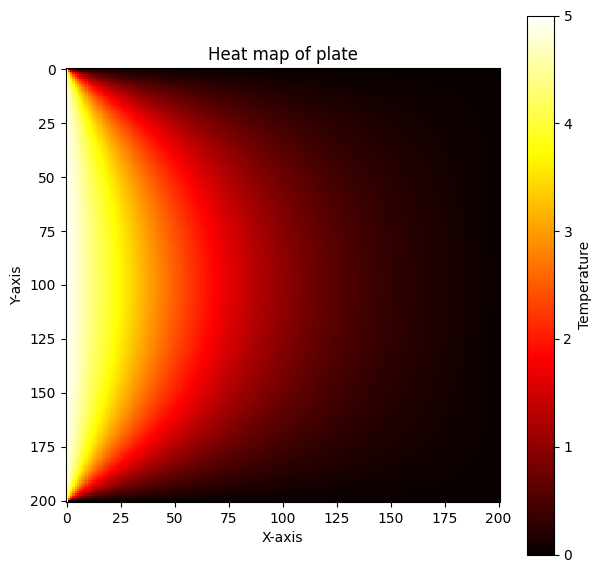

In [9]:
N = 201
dt = 1/(N+1)**2  #1/(N-1)**2 Largest possible dt while remaining stable
print(f"Maximum timestep dt is {1/(N+1)**2}:")

resC = Cuda_GPU_timemachine(N, dt)
plot_plate(resC['final_state'],N)

In [10]:
print(resC["u_cen"][-20:])
print(np.dtype(resC["u_cen"][0]))

[np.float64(0.9994454618540527), np.float64(0.9994757442145429), np.float64(0.9995060229241962), np.float64(0.9995362979834476), np.float64(0.9995665693927314), np.float64(0.999596837152482), np.float64(0.9996271012631344), np.float64(0.9996573617251224), np.float64(0.9996876185388809), np.float64(0.999717871704844), np.float64(0.9997481212234458), np.float64(0.9997783670951208), np.float64(0.9998086093203034), np.float64(0.9998388478994271), np.float64(0.9998690828329264), np.float64(0.9998993141212353), np.float64(0.9999295417647879), np.float64(0.9999597657640179), np.float64(0.9999899861193594), np.float64(1.000020202831246)]
float64


## GPU VS CPU speedup

Investigation into overall benefits of using GPU based funcionality across a range of NXN grids, to compare GPU overhead against scalability.


In [13]:
# CPU VS GPU speed for range of N X N grids, using ideal timestep
N_list = [127, 255, 511]
CPU_runtimes = []
GPU_runtimes = []
Speedups = []

for N in N_list:
    dt = 1/(N-1)**2  # Largest possible dt while remaining stable

    # Run CPU
    CPUres = Numba_CPU_timemachine(N, dt)
    CPU_runtimes.append(CPUres['runtime'])
    print('\n')

    # Run GPU
    GPUres = Cuda_GPU_timemachine(N, dt)
    GPU_runtimes.append(GPUres['runtime'])
    print('\n')

    # Calculate and print speedup immediately so you don't have to wait for N=511 to finish
    current_speedup = CPUres['runtime'] / GPUres['runtime']
    Speedups.append(current_speedup)
    print(f"=========================================")
    print(f" Speedup for N={N}: {current_speedup:.2f}x ")
    print(f"=========================================\n")


CPU_Numba
N: 127
dt: 6.298815822625347e-05
C: 0.25
Iteration 6600, Centre point u = 0.989650435936, t = 0.415721844293
Finished at iteration 6731, u_cen: 1.0000329937171966 t: 0.423973293021
Runtime: 1.0454039573669434 seconds


GPU_Cuda
N : 127
dt: 6.298815822625347e-05
C : 0.25

Finished at iteration 6731, u_cen: 1.000032993717 t: 0.423973293021
Runtime: 1.307166576385 seconds


 Speedup for N=127: 0.80x 

CPU_Numba
N: 255
dt: 1.5500031000062e-05
C: 0.25
Iteration 27200, Centre point u = 0.997030088647, t = 0.421600843202
Finished at iteration 27355, u_cen: 1.0000097634383323 t: 0.424003348007
Runtime: 17.7954807281494141 seconds


GPU_Cuda
N : 255
dt: 1.5500031000062e-05
C : 0.25
Iteration 20000, Centre point u = 0.811786949098, t = 0.310000620001
Finished at iteration 27355, u_cen: 1.000009763438 t: 0.424003348007
Runtime: 2.249110460281 seconds


 Speedup for N=255: 7.91x 

CPU_Numba
N: 511
dt: 3.844675124951942e-06
C: 0.25
Iteration 110200, Centre point u = 0.999599922810, t = 0.

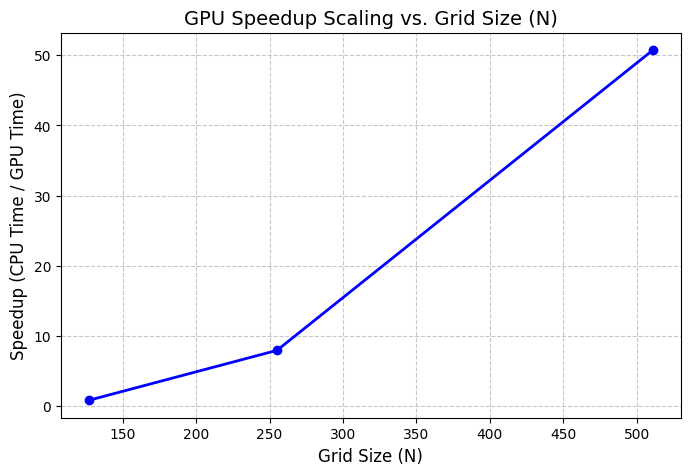

In [14]:
# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(N_list, Speedups, marker='o', linestyle='-', linewidth=2, color='b')

# Formatting the chart
plt.title('GPU Speedup Scaling vs. Grid Size (N)', fontsize=14)
plt.xlabel('Grid Size (N)', fontsize=12)
plt.ylabel('Speedup (CPU Time / GPU Time)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()


## Numeric investigation on stability
Stability of the numerical scheme is largely dependent on the chosen time step relative to the Courant-Friedrichs-Lewy (CFL) condition, which ensures convergence of the iterative solution. To test the stability of the scheme, I will use a series of simulations with time steps dt set at, below, and slightly above the Courant limit, dt_c =  By observing the behavior of the solution, such as whether it remains bounded or diverges, I can evaluate the impact of dt on stability, identifying dt/h^2 ≤ 1/4 as the CFL condition, giving
dt_c/h^2 = 1/4 as the maximum dt, from which dt_c = 1/(N+1)^2 can be pulled via
h = 2/(N-1).

Further, from condition we can see that dt/h^2 a useful value dubbed C in the time step calculation and also the Courant number should never exceed 0.25 which can be seen in above calculations.


In [46]:
N = 201
dt_c = 1/(N+1)**2
dt_list = np.arange(0.95,1.05,0.01,dtype = np.float64)

for i in range(len(dt_list)):
    dt = dt_list[i]*dt_c
    print(f"dt = {dt_list[i]}*dt_c \n")
    resCNI = Cuda_GPU_timemachine(N, dt)
    print('\n')


dt = 0.95*dt_c 

GPU_Cuda
N : 201
dt: 2.328203117341437e-05
C : 0.2328203117341437
Iteration 10000, Centre point u = 0.612033115569, t = 0.232820311734
Finished at iteration 18211, u_cen: 1.000002008279 t: 0.423989069699
Runtime: 3.735287904739 seconds


dt = 0.96*dt_c 

GPU_Cuda
N : 201
dt: 2.35271051857661e-05
C : 0.235271051857661
Iteration 10000, Centre point u = 0.619501972844, t = 0.235271051858
Finished at iteration 18022, u_cen: 1.000022567994 t: 0.424005489658
Runtime: 1.945424795151 seconds


dt = 0.97*dt_c 

GPU_Cuda
N : 201
dt: 2.377217919811783e-05
C : 0.2377217919811783
Iteration 10000, Centre point u = 0.626892807282, t = 0.237721791981
Finished at iteration 17836, u_cen: 1.000016840168 t: 0.424000588178
Runtime: 1.832809209824 seconds


dt = 0.98*dt_c 

GPU_Cuda
N : 201
dt: 2.401725321046956e-05
C : 0.2401725321046956
Iteration 10000, Centre point u = 0.634205869958, t = 0.240172532105
Finished at iteration 17654, u_cen: 1.000017155321 t: 0.424000588178
Runtime: 1.83591

The data demonstrates that the stability of our explicit scheme strongly depends on the time step dt relative to the Courant limit dt_c. As seen when  dt > 1.02 dt_c, the scheme becomes unstable with significant divergence, worsening as dt increases.

This instability from the Courant number. Representing the ratio of the physical distance a wave travels in one time step to the spatial resolution of the grid. This ratio is important as if the Courant number exceeds the threshold maximum, information effectively jumps across grid points invalidating the scheme's ability to
effectively solve the problem.

## Plotting scheme convergence towards t_ideal=0.424011387033
Due to the choice of an odd N, where N is the total number of spatial points per axis, the grid inherently has a well-defined center. This reduces the sensitivity of the results to N, as demonstrated by N=7, which provides suprsingly accurate results up to 4 decimal places small enough timestep. Therefore, for this convergence plot, I will again use N=201 which does not affect the accuracy of my desired dts. Further, the overall precision of the iterative method is fundamentally limited by the lowest decimal place in dt as well as the accuracy being constrained by the largest highest decimal place in dt, also as a consequence of the iterative approach forcing us to choose between precision and runtime. Under this regime the runtime must increase tenfold for each digit of precision. Using the below data where this pattern is apparent, assuming no error from N size calulaing to a prescion of 10^-12 would simply be an exercise in patience lasting roughly 2 years.

In [11]:
N = 7
dt = 1e-6  #1/(N-1)**2 Largest possible dt while remaining stable
print(f"Maximum timestep dt is {1/(N+1)**2}:")

resCN7 = Cuda_GPU_timemachine(N, dt)

Maximum timestep dt is 0.015625:
GPU_Cuda
N : 7
dt: 1e-06
C : 9e-06


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


Iteration 420000, Centre point u = 0.995036373010, t = 0.420000000000
Finished at iteration 424087, u_cen: 1.000001150444 t: 0.424087000000
Runtime: 19.161972522736 seconds


In [12]:
N = 201
t_ideal = 0.424011387033
dt_list = [1/(N+1)**2,1e-5,1e-6]
times = []

for i in range(len(dt_list)):
    import time as time # Band-aid solution
    dt = dt_list[i]
    print(f"dt = {dt_list[i]} \n")

    resCPS = Cuda_GPU_timemachine(N, dt)
    time = resCPS['final_time']

    times.append(time)
    print('\n')

dt = 2.450740123517302e-05 

GPU_Cuda
N : 201
dt: 2.450740123517302e-05
C : 0.2450740123517302
Iteration 10000, Centre point u = 0.648599866115, t = 0.245074012352
Finished at iteration 17301, u_cen: 1.000020202831 t: 0.424002548770
Runtime: 1.809898138046 seconds


dt = 1e-05 

GPU_Cuda
N : 201
dt: 1e-05
C : 0.1
Iteration 40000, Centre point u = 0.968590939999, t = 0.400000000000
Finished at iteration 42401, u_cen: 1.000010734049 t: 0.424010000000
Runtime: 2.256199121475 seconds


dt = 1e-06 

GPU_Cuda
N : 201
dt: 1e-06
C : 0.01
Iteration 420000, Centre point u = 0.995006073804, t = 0.420000000000
Finished at iteration 424011, u_cen: 1.000000394058 t: 0.424011000000
Runtime: 18.938024282455 seconds




Text(0, 0.5, 'Relative error')

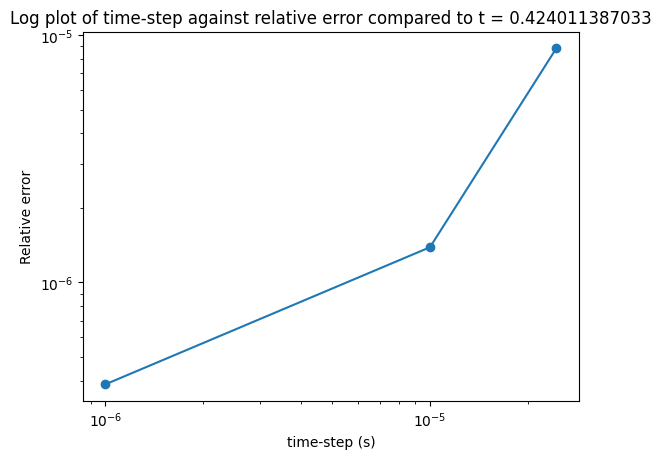

In [ ]:
# Plot results
diffs = np.zeros(len(times))
for i in range(len(times)):
    diffs[i] = t_ideal - times[i]

plt.title('Log plot of time-step against relative error compared to t = 0.424011387033')
plt.plot(dt_list, diffs, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('time-step (s)')
plt.ylabel('Relative error')

To further explore my hypothesis above I created a plot of the relative time error wrt N, using the largest and thus fastest dt to compute the simulation. From the data collected we can confrim that runtime and overall precision are roughly in line with previously obtained dt results which remais the main obstacle in precision. Interestingly however, is the lack of effect on runtime from increased N, most likely due to the GPU optimisations and five point stencil scheme used to simulate what would have been an N**2 by N**2 sparse matrix A.

Investigating wrt N using largest dt for relevant N gives the

---

following.

In [ ]:
N_list = np.array([101,201,401,801,1001])
times = []

for i in range(len(N_list)):
    import time as time # Band-aid solution
    N = N_list[i]
    print(f"N = {N_list[i]} \n")

    resCPSN = Cuda_GPU_timemachine(N, 1/(N+1)**2)

    time = resCPSN['final_time']
    times.append(time)
    print('\n')

N = 101 

GPU_Cuda
N : 101
dt: 9.611687812379854e-05
C : 0.24029219530949636


/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))



Finished at iteration 4411, u_cen: 1.000072826159 t: 0.423971549404
Runtime: 1.203764200211 seconds


N = 201 

GPU_Cuda
N : 201
dt: 2.450740123517302e-05
C : 0.2450740123517302
Iteration 10000, Centre point u = 0.648599866115, t = 0.245074012352
Finished at iteration 17301, u_cen: 1.000020202831 t: 0.424002548770
Runtime: 2.399421691895 seconds


N = 401 

GPU_Cuda
N : 401
dt: 6.187965644414742e-06
C : 0.2475186257765897
Iteration 60000, Centre point u = 0.925794280553, t = 0.371277938665
Finished at iteration 68521, u_cen: 1.000000710965 t: 0.424005593921
Runtime: 3.470136642456 seconds


N = 801 

GPU_Cuda
N : 801
dt: 1.554716699523013e-06
C : 0.24875467192368209
Iteration 270000, Centre point u = 0.994722117910, t = 0.419773508871
Finished at iteration 272725, u_cen: 1.000000401120 t: 0.424010111877
Runtime: 25.810388803482 seconds


N = 1001 

GPU_Cuda
N : 1001
dt: 9.960119680798084e-07
C : 0.2490029920199521
Iteration 420000, Centre point u = 0.992891386996, t = 0.418325026594
F

Text(0, 0.5, 'Relative error')

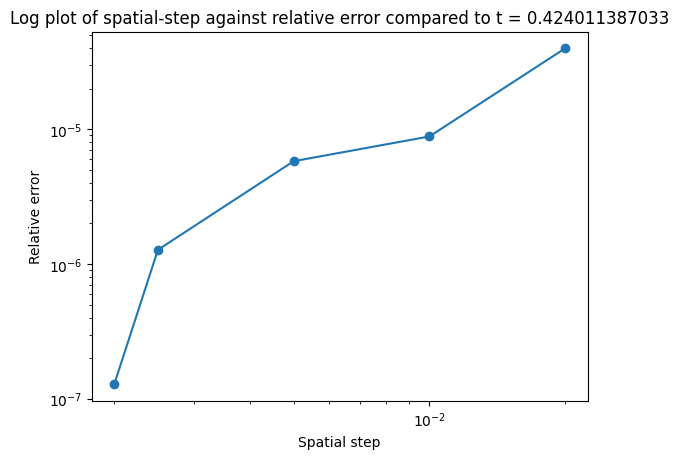

In [ ]:
# Plot results
Ndiffs = np.zeros(len(times))
for i in range(len(times)):
    Ndiffs[i] = t_ideal - times[i]

plt.title('Log plot of spatial-step against relative error compared to t = 0.424011387033')
plt.plot(2/(N_list-1), Ndiffs, marker='o', linestyle='-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Spatial step')
plt.ylabel('Relative error')

# Precision tests

t_ideal=0.424011387033

Maximum timestep dt is 9.960119680798084e-07:
GPU_Cuda
N : 1001
dt: 1e-07
C : 0.024999999999999998
Iteration 4240000, Centre point u = 0.999986072107, t = 0.424000000000
Finished at iteration 4240113, u_cen: 1.000000004684 t: 0.424011300000
Runtime: 535.786796331406 seconds


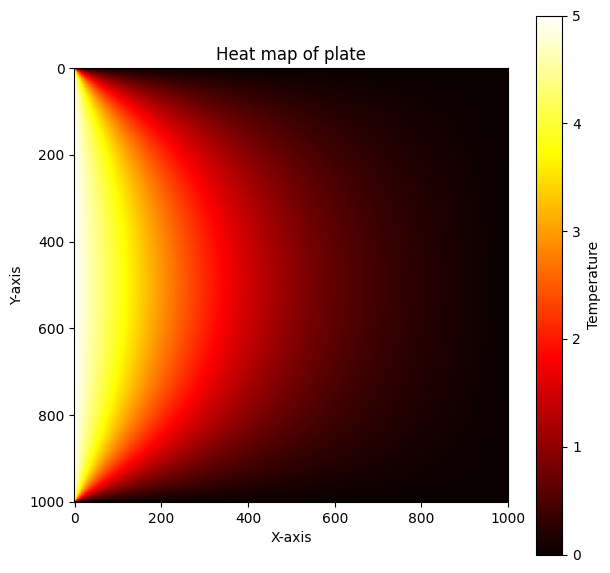

In [ ]:
# Attempt at 7d.p. prescision
import time as time # Band-aid solution
N = 1001
dt = 1e-7
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res7dp = Cuda_GPU_timemachine(N, dt)
plot_plate(res7dp['final_state'],N)

In [ ]:
# 8d.p
import time as time # Band-aid solution
N = 2001
dt = 1e-8
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res8dp = Cuda_GPU_timemachine(N, dt)
plot_plate(res8dp['final_state'],N)

Maximum timestep dt is 2.495007490012485e-07:
GPU_Cuda
N : 2001
dt: 1e-08
C : 0.01
Iteration 640000, Centre point u = 0.000000000000, t = 0.006400000000

In [ ]:
# 9d.p
import time as time # Band-aid solution
N = 2001
dt = 1e-9
print(f"Maximum timestep dt is {1/(N+1)**2}:")

res9dp = Cuda_GPU_timemachine(N, dt)
plot_plate(res8dp['final_state'],N)

Maximum timestep dt is 2.495007490012485e-07:
GPU_Cuda
N : 2001
dt: 4.24011387033e-08
C : 0.0424011387033
Iteration 9990000, Centre point u = 0.999476725204, t = 0.423587375646
Finished at iteration 10000000, u_cen: 1.000000050374 t: 0.424011387033
Runtime: 5106.958461284637 seconds


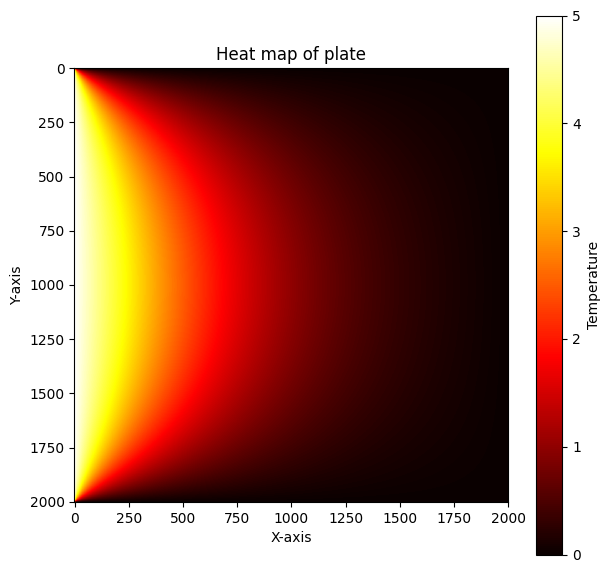

In [ ]:
# Matrix error test.
import time as time # Band-aid solution
t_ideal = 0.424011387033
N = 2001
dt = t_ideal/1e7 # Use a factor of ideal solution
print(f"Maximum timestep dt is {1/(N+1)**2}:")

resCTC = Cuda_GPU_timemachine(N, dt)
plot_plate(resCTC['final_state'],N)